# Modeling Projection Effects in Optically Selected Clusters

This tutorial demonstrates how to evaluate the projection effect in cluster richness using the model from [Costanzi et al. 2019 (arXiv:1807.07072)](https://arxiv.org/abs/1807.07072). For detailed background and physical derivations, please refer to the original paper.

The projection effect modifies the observed richness ($\lambda_{\mathrm{ob}}$) given a true intrinsic richness ($\lambda_{\mathrm{tr}}$). This is parameterized as **Equation 15 in Costanzi et al. 2019**.


## 1. Evaluating $P(\lambda_{\mathrm{ob}} | \lambda_{\mathrm{tr}})$

* This is done by the function `prob_richobs_at_richtru`, which takes the following parameters:

  **Parameters:**
  * `rich_obs` *(array)*: Array of observed richness values ($\lambda_{\mathrm{ob}}$).
  * `rich_tru` *(array)*: True intrinsic richness ($\lambda_{\mathrm{tr}}$).
  * `tau` *(array)*: The decay scale of the exponential tail for chance projections.
  * `delta_mu` *(array)*: Mean shift in richness due to noise.
  * `sig_pure` *(array)*: Intrinsic scatter of the richness estimate.
  * `fprj` *(array)*: Fraction of clusters affected by projection effects.
  * `fmsk` *(array)*: Fraction of clusters maksed due to masking or percolaion.

  **Output:**
  * `pdf`*(array)*: Array of $P(\lambda_{\mathrm{ob}} | \lambda_{\mathrm{tr}})$ in the shape of `(len(rich_obs), len(rich_tru))`.

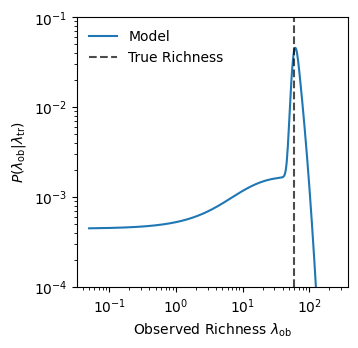

In [1]:
import os
# turnoff the openmp
os.environ["OMP_NUM_THREADS"] = "1"
import numpy as np
import matplotlib.pyplot as plt
from crow.cluster_modules.projection_effects import CostanziRichnessBias

# Define input arrays
rich_obs = np.geomspace(5E-2, 250, 500)   # evaluate at observed richness in logarithmical steps
rich_tru = np.array([ 60.0 ])             # consider a true richness at 60

# Define model parameters
params = {
         'tau': 0.10,
    'delta_mu': -1.0,
    'sig_pure':  5.0,
        'fprj': 0.80,
        'fmsk': 0.10,
}

# Evaluate the probability distribution in shape of (len(rich_obs), 1)
prob_dist = CostanziRichnessBias.prob_richobs_at_richtru(
            rich_obs=rich_obs, 
            rich_tru=rich_tru, 
            **params
            )

# Plot the result
plt.figure(figsize=(3.5, 3.5))
plt.plot(rich_obs, prob_dist[:,0], label=r'Model')
plt.axvline(rich_tru[0], color='black', linestyle='--', alpha=0.7, label=r'True Richness')
plt.xlabel(r'Observed Richness $\lambda_{\mathrm{ob}}$')
plt.ylabel(r'$P(\lambda_{\mathrm{ob}} | \lambda_{\mathrm{tr}})$')
plt.xscale("log")
plt.yscale("log")
plt.ylim(1E-4,0.1)
plt.legend(frameon=False)
plt.show()

* The evaluation of $P(\lambda_{\mathrm{ob}} | \lambda_{\mathrm{tr}})$ can be performed for an array of the true richness $\lambda_{\mathrm{tr}}$.

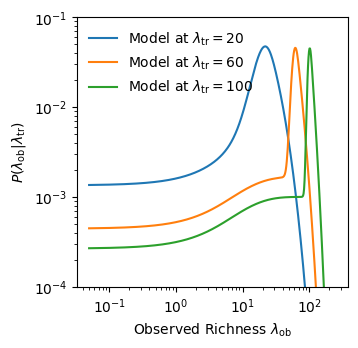

In [2]:
# Define input arrays
rich_tru_array = np.array([ 20, 60.0, 100 ])    # an array of true richness

# Evaluate the probability distribution
prob_dist = CostanziRichnessBias.prob_richobs_at_richtru(
            rich_obs=rich_obs, 
            rich_tru=rich_tru_array, 
            **params
            )

# Plot the result
plt.figure(figsize=(3.5, 3.5))
for i in range(len(rich_tru_array)):
    plt.plot(rich_obs, prob_dist[:,i], label=r'Model at $\lambda_{\mathrm{tr}} = %2i$' % rich_tru_array[i])
plt.xlabel(r'Observed Richness $\lambda_{\mathrm{ob}}$')
plt.ylabel(r'$P(\lambda_{\mathrm{ob}} | \lambda_{\mathrm{tr}})$')
plt.xscale("log")
plt.yscale("log")
plt.ylim(1E-4,0.1)
plt.legend(frameon=False)
plt.show()

* The function `prob_richobs_at_richtru` can evaluate $P(\lambda^{\mathrm{ob}} | \lambda^{\mathrm{tr}})$ for an array of parameters. This is particularly useful if the parameters are dependent on the true richness. 
In this case, the parameter array must have the same shape as `rich_tru`.

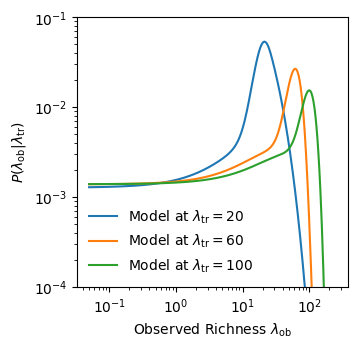

In [5]:
# Define model parameters
params_array = {
         'tau': np.array([0.10, 0.2, 0.3]),
    'delta_mu': -1.0,
    'sig_pure': 0.20 * rich_tru_array,  # 20% scatter
        'fprj': np.array([0.8, 0.8, 0.9]),
        'fmsk': np.array([0.1,0.2, 0.3]),
}

# Evaluate the probability distribution in a shape of (len(rich_obs), len(rich_tru_array))
prob_dist = CostanziRichnessBias.prob_richobs_at_richtru(
            rich_obs=rich_obs, 
            rich_tru=rich_tru_array, 
            **params_array
            )

# Plot the result
plt.figure(figsize=(3.5, 3.5))
for i in range(len(rich_tru_array)):
    plt.plot(rich_obs, prob_dist[:,i], label=r'Model at $\lambda_{\mathrm{tr}} = %2i$' % rich_tru_array[i])
plt.xlabel(r'Observed Richness $\lambda_{\mathrm{ob}}$')
plt.ylabel(r'$P(\lambda_{\mathrm{ob}} | \lambda_{\mathrm{tr}})$')
plt.xscale("log")
plt.yscale("log")
plt.ylim(1E-4,0.1)
plt.legend(frameon=False)
plt.show()

## 2. Evaluating $\int P(\lambda^{\mathrm{ob}} | \lambda^{\mathrm{tr}}) \mathrm{d}\lambda^{\mathrm{ob}}$

In practical applications, we often need the probability integrated over specific observed richness bins. This is given by:

$$S = \int_{\lambda_{\mathrm{min}}}^{\lambda_{\mathrm{max}}} P(\lambda_{\mathrm{ob}} | \lambda_{\mathrm{tr}}) d\lambda_{\mathrm{ob}}$$



The function `Sprob_at_richtru` evaluates this integral over specified intervals.

**Additional Parameters:**
* `rich_obs_eds` *(array)*: 1D array of boundaries defining the richness intervals (must be monotonically increasing).
* `rich_obs_res` *(array)*: Resolution used in the numerical integration over each interval (smaller values mean higher resolution).

**Outputs:**
* integrated_prob (array): A 2D array of the integrated probability values with the shape (len(rich_tru), len(rich_obs_eds) - 1). Each element represents the probability of a cluster with a given true richness falling into a specific observed richness bin.

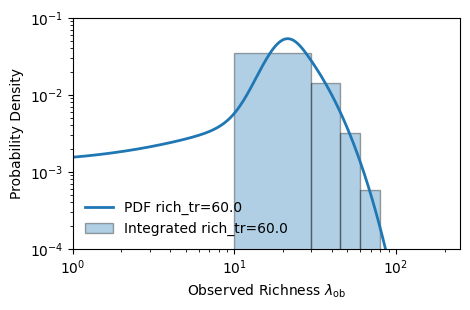

In [6]:
# Define integration boundaries and resolution
edges = np.array([10,30.0, 45.0, 60.0, 80.0, 110.0])
resolution = 0.01

# the integrated prob in shape of (len(edges) - 1, len(rich_tru))
integrated_prob = CostanziRichnessBias.Sprob_at_richtru(
    rich_obs_eds=edges,
    rich_obs_res=resolution,
    rich_tru=rich_tru_array,
    **params_array
)


# Bin properties
bin_centers = (edges[:-1] + edges[1:]) / 2
bin_widths = np.diff(edges)

plt.figure(figsize=(5,3))

# Integrated probabilities
for i in range(len(rich_tru)):

    yvals = np.asarray(integrated_prob[:, i]).flatten()

    density_vals = yvals / bin_widths[:len(yvals)]

    plt.bar(
        bin_centers[:len(yvals)],
        density_vals,
        width=bin_widths[:len(yvals)],
        alpha=0.35,
        edgecolor='black',
        label=f'Integrated rich_tr={rich_tru[i]}'
    )

# PDFs
for i in range(len(rich_tru)):

    plt.plot(
        rich_obs,
        prob_dist[:, i],
        linewidth=2,
        label=f'PDF rich_tr={rich_tru[i]}'
    )

plt.xlabel(r'Observed Richness $\lambda_{\rm ob}$')
plt.ylabel('Probability Density')
plt.loglog()
plt.ylim([1E-4,0.1])
plt.xlim([1,250])
plt.legend(frameon=False)
plt.show()

## 3. Performance Profiling


In [7]:
# --- Section 3: Performance Profiling Results ---

n_rich_obs_test = 500
n_rich_true_test = 5000

test_rich_obs = np.linspace(30, 110, n_rich_obs_test)
test_rich_tru = np.linspace(30, 110, n_rich_true_test)
test_edges = np.linspace(30, 110, n_rich_obs_test + 1)

# Ensure parameters are broadcastable
profiling_params = {k: (v[0] if isinstance(v, (np.ndarray, list)) else v) for k, v in params.items()}

print(f"Profiling: {n_rich_obs_test} bins x {n_rich_true_test} true richness")

print("\n1. Continuous PDF Performance:")
%timeit CostanziRichnessBias.prob_richobs_at_richtru(test_rich_obs, test_rich_tru, **profiling_params)

print("\n2. Binned Integration Performance:")
%timeit CostanziRichnessBias.Sprob_at_richtru(test_edges, resolution, test_rich_tru, **profiling_params)

Profiling: 500 bins x 5000 true richness

1. Continuous PDF Performance:
89 ms ± 1.41 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

2. Binned Integration Performance:
9.13 ms ± 259 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
